Loading dataset...
Dataset shape: (9453, 26)

========== STARTING 5-FOLD TRAINING ==========

--- Fold 1/5 ---
Fruit Accuracy: 0.9799048122686409
Freshness Accuracy: 0.9894235854045479

--- Fold 2/5 ---
Fruit Accuracy: 0.9777895293495505
Freshness Accuracy: 0.9846641988365944

--- Fold 3/5 ---
Fruit Accuracy: 0.9825489159175039
Freshness Accuracy: 0.985193019566367

--- Fold 4/5 ---
Fruit Accuracy: 0.9814814814814815
Freshness Accuracy: 0.9841269841269841

--- Fold 5/5 ---
Fruit Accuracy: 0.9835978835978836
Freshness Accuracy: 0.9841269841269841

========== TRAINING COMPLETE ==========
   Fold  Accuracy (%)  Precision (%)  Recall (%)  Sensitivity (%)  \
0     1     98.942359      99.259944   98.894009        98.894009   
1     2     98.466420      98.440367   98.894009        98.894009   
2     3     98.519302      98.354662   99.079190        99.079190   
3     4     98.412698      97.910990   99.354839        99.354839   
4     5     98.412698      98.887859   98.341014        98.341

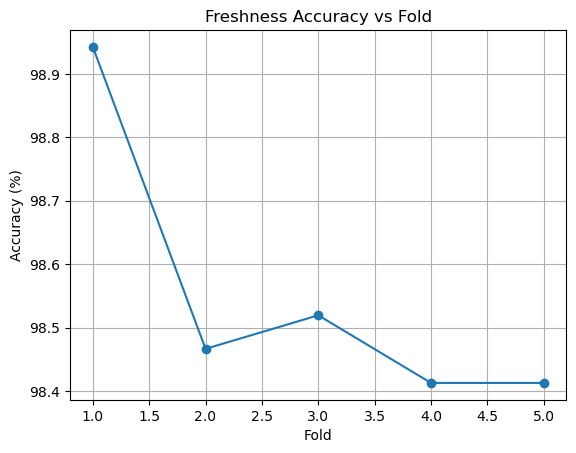

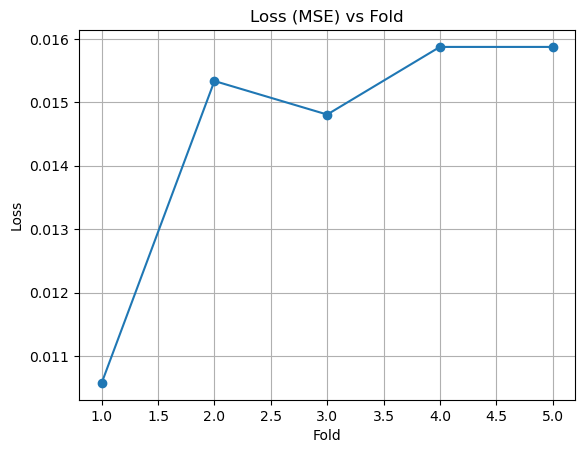


Prediction: Apple - Fresh


In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error,
    confusion_matrix, log_loss, r2_score
)
from sklearn.ensemble import RandomForestClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

# ============================================================
# FEATURE EXTRACTION
# ============================================================
def extract_features(img):
    img = cv2.resize(img, (256, 256))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]

    s_blur = cv2.GaussianBlur(s, (5, 5), 0)
    _, mask = cv2.threshold(s_blur, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    circularity = (4*np.pi*area)/(perimeter**2 + 1e-6)

    hull = cv2.convexHull(cnt)
    solidity = area/(cv2.contourArea(hull) + 1e-6)

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w/(h + 1e-6)
    extent = area/(w*h + 1e-6)

    R, G, B = cv2.split(img)
    H, S, V = cv2.split(hsv)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_masked = cv2.bitwise_and(gray, gray, mask=mask)

    lap_var = cv2.Laplacian(gray_masked, cv2.CV_64F).var()

    glcm = graycomatrix(gray_masked, [1], [0], 256,
                        symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    hist = cv2.calcHist([gray_masked], [0], mask, [256], [0, 256])
    hist /= (hist.sum() + 1e-6)
    ent = entropy(hist.flatten())

    dark_ratio = np.sum(gray_masked < 50)/(np.sum(mask > 0) + 1e-6)

    return [
        np.mean(R), np.mean(G), np.mean(B),
        np.std(R), np.std(G), np.std(B),
        np.mean(H), np.mean(S), np.mean(V),
        np.std(H), np.std(S), np.std(V),
        lap_var, contrast, energy, homogeneity,
        ent, area, perimeter, circularity, solidity,
        aspect_ratio, extent, dark_ratio
    ]

# ============================================================
# LOAD DATASET
# ============================================================
dataset_path = r"C:\Users\KIIT0001\Desktop\fruit_freshness3\dataset\train"
print("Loading dataset...")
data = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    name = folder.lower()

    # Freshness label
    if "rotten" in name:
        freshness = "Rotten"
    else:
        freshness = "Fresh"

    # Fruit label
    if "apple" in name:
        fruit = "Apple"
    elif "banana" in name:
        fruit = "Banana"
    elif "orange" in name:
        fruit = "Orange"
    else:
        fruit = "Unknown"

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        feat = extract_features(img)
        if feat is not None:
            data.append(feat + [fruit, freshness])

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)

# ============================================================
# PREPROCESSING
# ============================================================
X = df.iloc[:, :-2]

fruit_labels = df.iloc[:, -2]
fresh_labels = df.iloc[:, -1]

le_fruit = LabelEncoder()
y_fruit = le_fruit.fit_transform(fruit_labels)

le_fresh = LabelEncoder()
y_fresh = le_fresh.fit_transform(fresh_labels)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ============================================================
# K-FOLD TRAINING
# ============================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
fold_acc = []
fold_loss = []

start = time.time()

print("\n========== STARTING 5-FOLD TRAINING ==========")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_fresh), 1):
    print(f"\n--- Fold {fold}/5 ---")

    X_train, X_test = X[train_idx], X[test_idx]

    y_fruit_train, y_fruit_test = y_fruit[train_idx], y_fruit[test_idx]
    y_fresh_train, y_fresh_test = y_fresh[train_idx], y_fresh[test_idx]

    fruit_model = RandomForestClassifier(n_estimators=100, random_state=42)
    fresh_model = RandomForestClassifier(n_estimators=100, random_state=42)

    fruit_model.fit(X_train, y_fruit_train)
    fresh_model.fit(X_train, y_fresh_train)

    fruit_pred = fruit_model.predict(X_test)
    fresh_pred = fresh_model.predict(X_test)
    y_prob = fresh_model.predict_proba(X_test)

    # Metrics (Freshness)
    acc = accuracy_score(y_fresh_test, fresh_pred)
    prec = precision_score(y_fresh_test, fresh_pred)
    rec = recall_score(y_fresh_test, fresh_pred)
    f1 = f1_score(y_fresh_test, fresh_pred)

    tn, fp, fn, tp = confusion_matrix(y_fresh_test, fresh_pred).ravel()
    sensitivity = tp/(tp + fn)

    mse = mean_squared_error(y_fresh_test, fresh_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_fresh_test, fresh_pred)
    ll = log_loss(y_fresh_test, y_prob)
    r2 = r2_score(y_fresh_test, fresh_pred)

    fruit_acc = accuracy_score(y_fruit_test, fruit_pred)

    fold_acc.append(acc*100)
    fold_loss.append(mse)

    print(f"Fruit Accuracy: {fruit_acc}")
    print(f"Freshness Accuracy: {acc}")

    results.append([
        fold, acc*100, prec*100, rec*100,
        sensitivity*100, f1*100, len(y_fresh_test),
        mse, rmse, mae, ll, r2
    ])

# ============================================================
# SUMMARY
# ============================================================
results_df = pd.DataFrame(results, columns=[
    "Fold", "Accuracy (%)", "Precision (%)", "Recall (%)",
    "Sensitivity (%)", "F1 Score (%)", "Support",
    "MSE", "RMSE", "MAE", "Log Loss", "R2 Score"
])

print("\n========== TRAINING COMPLETE ==========")
print(results_df)
print("\nAVERAGE METRICS")
print(results_df.mean(numeric_only=True))

print(f"\nTOTAL TIME: {time.time()-start:.2f} sec")

# ============================================================
# GRAPHS
# ============================================================
plt.figure()
plt.plot(range(1,6), fold_acc, marker='o')
plt.title("Freshness Accuracy vs Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

plt.figure()
plt.plot(range(1,6), fold_loss, marker='o')
plt.title("Loss (MSE) vs Fold")
plt.xlabel("Fold")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ============================================================
# FINAL PREDICTION FUNCTION
# ============================================================
def predict_image(image_path):
    img = cv2.imread(image_path)

    feat = extract_features(img)
    if feat is None:
        return "No fruit detected"

    feat = scaler.transform([feat])

    fruit_pred = fruit_model.predict(feat)
    fresh_pred = fresh_model.predict(feat)

    fruit_name = le_fruit.inverse_transform(fruit_pred)[0]
    freshness = le_fresh.inverse_transform(fresh_pred)[0]

    return f"{fruit_name} - {freshness}"

# TEST
test_img = r"C:\Users\KIIT0001\Desktop\test_images\Screen Shot 2018-06-08 at 4.59.36 PM.png"
print("\nPrediction:", predict_image(test_img))

In [2]:
test_img = r"C:\Users\KIIT0001\Desktop\test_images\orange.jpg"
print("\nPrediction:", predict_image(test_img))


Prediction: Orange - Fresh


In [3]:
test_img = r"C:\Users\KIIT0001\Desktop\test_images\kola.jpg"
print("\nPrediction:", predict_image(test_img))


Prediction: Banana - Rotten


In [4]:
test_img = r"C:\Users\KIIT0001\Desktop\test_images\pexels-pixabay-161559.jpg"
print("\nPrediction:", predict_image(test_img))


Prediction: Orange - Rotten


In [ ]:
test_img = r"C:\Users\KIIT0001\Desktop\test_images\orn.jpg"
print("\nPrediction:", predict_image(test_img))